# 02. Data coarse-graining and empirical diagnostics

This notebook is the public/release version of the empirical data coarse-graining notebook.

Input rule:

- If `./data/SP_monthly_sector_and_all.csv` exists, the notebook uses it.
- Otherwise it uses `./data/SAMPLE.csv`.

The real data file is proprietary and is not included in the public repository.  
`SAMPLE.csv` is synthetic low-fidelity data for workflow demonstration only, and is not intended to reproduce the empirical numerical results in the paper.

Outputs:

- coarse-grained data: `./pdata/SP_monthly_sector_and_all_kmonth.csv`
- tables: `./tables/*.csv`
- figures: `./figures/*.png` and `./figures/*.pdf`

In [1]:
# ============================================================
# 0. Setup
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_DIR = Path("data")
PDATA_DIR = Path("pdata")
FIG_DIR = Path("figures")
TABLE_DIR = Path("tables")

for d in [DATA_DIR, PDATA_DIR, FIG_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

REAL_INPUT_PATH = DATA_DIR / "SP_monthly_sector_and_all.csv"
SAMPLE_INPUT_PATH = DATA_DIR / "SAMPLE.csv"

if REAL_INPUT_PATH.exists():
    INPUT_PATH = REAL_INPUT_PATH
    DATA_SOURCE = "real"
elif SAMPLE_INPUT_PATH.exists():
    INPUT_PATH = SAMPLE_INPUT_PATH
    DATA_SOURCE = "sample"
else:
    raise FileNotFoundError(
        "No input CSV found. Expected either:\n"
        f"  {REAL_INPUT_PATH}\n"
        f"  {SAMPLE_INPUT_PATH}\n\n"
        "Run 01_generate_synthetic_multisector_data.ipynb first, "
        "or place the real data file in ./data/."
    )

K_LIST = [1, 2, 3, 4, 6, 12]
MAX_LAG_MONTHS = 36

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

def savefig(fig, name):
    png = FIG_DIR / f"{name}.png"
    pdf = FIG_DIR / f"{name}.pdf"
    fig.savefig(png, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    print(f"saved: {png}")
    print(f"saved: {pdf}")

def save_table(df, name, index=False):
    path = TABLE_DIR / f"{name}.csv"
    df.to_csv(path, index=index)
    print(f"saved: {path}")
    display(df.head(20))

def require_columns(df, cols, name="DataFrame"):
    missing = set(cols) - set(df.columns)
    if missing:
        raise ValueError(f"{name} is missing required columns: {sorted(missing)}")

In [2]:
# ============================================================
# 1. Load monthly multi-sector default-count panel
# ============================================================

df_ms = pd.read_csv(INPUT_PATH)

required = [
    "date", "sector", "bonds", "defaulted",
]
require_columns(df_ms, required, "monthly multi-sector data")

df_ms["date"] = pd.to_datetime(df_ms["date"])
df_ms = df_ms.sort_values(["sector", "date"]).reset_index(drop=True)

df_ms["year"] = df_ms["date"].dt.year
df_ms["month"] = df_ms["date"].dt.month
df_ms["default_rate"] = df_ms["defaulted"] / df_ms["bonds"]

SECTORS_ALL = sorted(df_ms["sector"].unique())
SECTORS = [s for s in SECTORS_ALL if s != "ALL"]

print("Input:", INPUT_PATH)
print("Data source:", DATA_SOURCE)
print("n rows:", len(df_ms))
print("sectors including ALL:", len(SECTORS_ALL), SECTORS_ALL)
print("sectors excluding ALL:", len(SECTORS), SECTORS)

display(df_ms.head())

# Basic consistency check: ALL should be present for portfolio-level diagnostics.
if "ALL" not in SECTORS_ALL:
    print("Warning: sector 'ALL' was not found. Portfolio-level ALL diagnostics will be unavailable.")

Input: data\SP_monthly_sector_and_all.csv
Data source: real
n rows: 6846
sectors including ALL: 14 ['ALL', 'Consumer', 'Energy', 'FI', 'Forest', 'Health', 'High Tech', 'Insurance', 'Leisure', 'Metal', 'Real Estate', 'Telecom', 'Transport', 'Utility']
sectors excluding ALL: 13 ['Consumer', 'Energy', 'FI', 'Forest', 'Health', 'High Tech', 'Insurance', 'Leisure', 'Metal', 'Real Estate', 'Telecom', 'Transport', 'Utility']


,date,year,month,quarter,half,sector,bonds,defaulted,upgrade,same,downgrade,non_rated,default_rate
0,1981-01-31,1981,1,1,1,ALL,1342,0,4,1290,45,3,0.000000
1,1981-02-28,1981,2,1,1,ALL,1353,1,6,1327,16,3,0.000739
2,1981-03-31,1981,3,1,1,ALL,1359,0,6,1336,16,1,0.000000
3,1981-04-30,1981,4,2,1,ALL,1367,0,6,1346,13,2,0.000000
4,1981-05-31,1981,5,2,1,ALL,1370,0,3,1357,6,4,0.000000


## Table 1. Monthly data summary by sector

This table documents the monthly multi-sector default-count panel used in the empirical analysis.  
When `SAMPLE.csv` is used, the table is only a workflow check.

In [3]:
# ============================================================
# 2. Table: sector-level monthly data summary
# ============================================================

table_data_summary = (
    df_ms
    .groupby("sector")
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        n_months=("date", "size"),
        mean_obligors=("bonds", "mean"),
        min_obligors=("bonds", "min"),
        max_obligors=("bonds", "max"),
        total_defaults=("defaulted", "sum"),
        mean_monthly_defaults=("defaulted", "mean"),
        mean_monthly_default_rate=("default_rate", "mean"),
        sd_monthly_default_rate=("default_rate", "std"),
    )
    .reset_index()
)

table_data_summary["approx_annual_default_rate"] = (
    12.0 * table_data_summary["mean_monthly_default_rate"]
)

for col in ["start_date", "end_date"]:
    table_data_summary[col] = pd.to_datetime(table_data_summary[col]).dt.strftime("%Y-%m")

save_table(table_data_summary, "table01_monthly_data_summary_by_sector")

saved: tables\table01_monthly_data_summary_by_sector.csv


,sector,start_date,end_date,n_months,mean_obligors,min_obligors,max_obligors,total_defaults,mean_monthly_defaults,mean_monthly_default_rate,sd_monthly_default_rate,approx_annual_default_rate
0,ALL,1981-01,2021-09,489,3912.208589,1342,6287,2451,5.012270,0.001231,0.001161,0.014768
1,Consumer,1981-01,2021-09,489,441.683027,226,757,443,0.905930,0.001960,0.002672,0.023522
2,Energy,1981-01,2021-09,489,249.128834,89,532,374,0.764826,0.002406,0.004530,0.028877
3,FI,1981-01,2021-09,489,676.995910,87,1117,179,0.366053,0.000528,0.001313,0.006334
4,Forest,1981-01,2021-09,489,142.237219,65,223,140,0.286299,0.002009,0.005024,0.024106
5,Health,1981-01,2021-09,489,244.595092,69,483,138,0.282209,0.001078,0.002534,0.012937
6,High Tech,1981-01,2021-09,489,157.891616,61,335,78,0.159509,0.001096,0.003290,0.013146
7,Insurance,1981-01,2021-09,489,494.008180,33,805,59,0.120654,0.000370,0.002322,0.004443
8,Leisure,1981-01,2021-09,489,242.261759,43,387,326,0.666667,0.002613,0.004677,0.031351
9,Metal,1981-01,2021-09,489,392.132924,217,589,321,0.656442,0.001613,0.002984,0.019358


In [4]:
# ============================================================
# 3. Observed-data temporal coarse-graining rule
# ============================================================

def aggregate_k_month(df_monthly_one_sector, k, drop_incomplete=True):
    """Aggregate one sector into non-overlapping k-month blocks.

    Exposure n is the number of obligors at the first month of the block.
    Defaults L are summed within the block.
    The monthly-equivalent default rate is (L / n) / k.
    """
    d = df_monthly_one_sector.sort_values("date").reset_index(drop=True).copy()
    rows = []
    n_blocks = len(d) // k if drop_incomplete else int(np.ceil(len(d) / k))

    for b in range(n_blocks):
        block = d.iloc[b*k:(b+1)*k].copy()
        if drop_incomplete and len(block) < k:
            continue

        first = block.iloc[0]
        last = block.iloc[-1]
        n_start = float(first["bonds"])
        L_sum = float(block["defaulted"].sum())

        rows.append({
            "k_month": k,
            "block_id": b,
            "start_date": first["date"],
            "end_date": last["date"],
            "year_start": int(first["year"]),
            "month_start": int(first["month"]),
            "n": n_start,
            "L": L_sum,
            "default_rate": L_sum / n_start,
            "default_rate_per_month": (L_sum / n_start) / k,
        })

    return pd.DataFrame(rows)

def make_sector_panel(df_kmonth, k, value="default_rate_per_month", include_all=False):
    d = df_kmonth.query("k_month == @k").copy()
    if not include_all:
        d = d.query("sector != 'ALL'").copy()

    panel = (
        d.pivot_table(
            index="start_date",
            columns="sector",
            values=value,
            aggfunc="first",
        )
        .sort_index()
    )
    return panel

df_kmonth_list = []

for sector, g in df_ms.groupby("sector", sort=True):
    for k in K_LIST:
        tmp = aggregate_k_month(g, k=k, drop_incomplete=True)
        tmp.insert(0, "sector", sector)
        df_kmonth_list.append(tmp)

df_kmonth_sector = pd.concat(df_kmonth_list, ignore_index=True)

out_path = PDATA_DIR / "SP_monthly_sector_and_all_kmonth.csv"
df_kmonth_sector.to_csv(out_path, index=False)
print("saved:", out_path)

block_count_table = (
    df_kmonth_sector
    .groupby(["sector", "k_month"])
    .size()
    .rename("n_blocks")
    .reset_index()
)

save_table(block_count_table, "table02_kmonth_block_counts_by_sector")

saved: pdata\SP_monthly_sector_and_all_kmonth.csv
saved: tables\table02_kmonth_block_counts_by_sector.csv


,sector,k_month,n_blocks
0,ALL,1,489
1,ALL,2,244
2,ALL,3,163
3,ALL,4,122
4,ALL,6,81
5,ALL,12,40
6,Consumer,1,489
7,Consumer,2,244
8,Consumer,3,163
9,Consumer,4,122


## Figure S1. Quarterly sector default-rate heatmap

This diagnostic visualizes sectoral stress episodes using non-overlapping three-month blocks.  
The grayscale version is used to keep the figure compatible with black-and-white publication.

saved: figures\figS01_quarterly_sector_default_rate_heatmap_grayscale.png
saved: figures\figS01_quarterly_sector_default_rate_heatmap_grayscale.pdf


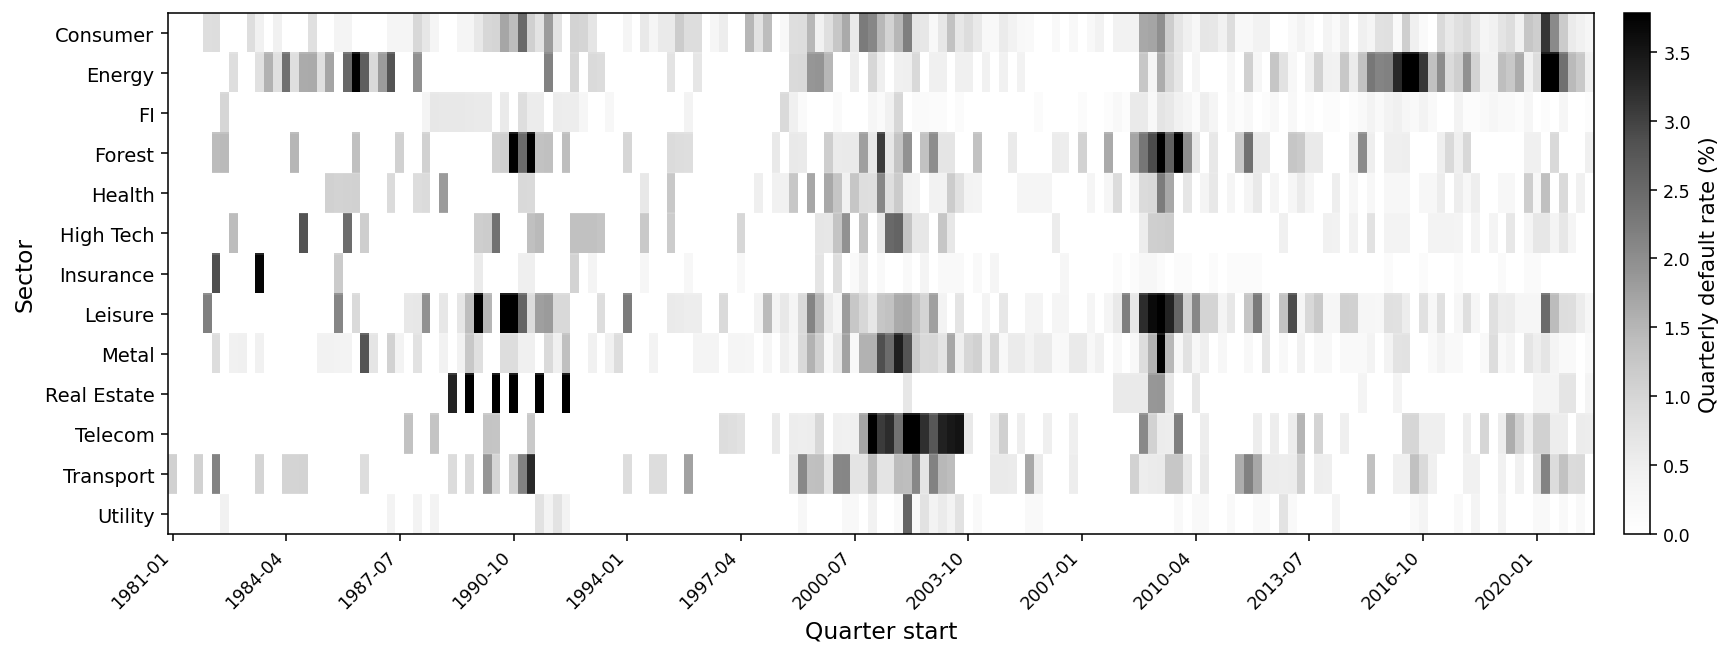

In [5]:
# ============================================================
# Figure S1: quarterly sector default-rate heatmap
# ============================================================

panel_quarterly_rate = make_sector_panel(
    df_kmonth_sector,
    k=3,
    value="default_rate",
    include_all=False,
)

Z = 100.0 * panel_quarterly_rate.T.values
sectors = list(panel_quarterly_rate.columns)

dates = pd.to_datetime(panel_quarterly_rate.index)
date_labels = dates.strftime("%Y-%m").tolist()

fig, ax = plt.subplots(figsize=(12.5, 4.8))

vmax = np.nanpercentile(Z, 99.0)

im = ax.imshow(
    Z,
    aspect="auto",
    interpolation="nearest",
    cmap="Greys",
    vmin=0,
    vmax=vmax,
)

ax.set_yticks(np.arange(len(sectors)))
ax.set_yticklabels(sectors, fontsize=10)

tick_step = max(1, len(date_labels) // 12)
xticks = np.arange(0, len(date_labels), tick_step)
ax.set_xticks(xticks)
ax.set_xticklabels([date_labels[i] for i in xticks], rotation=45, ha="right", fontsize=9)

ax.set_xlabel("Quarter start", fontsize=12)
ax.set_ylabel("Sector", fontsize=12)

for y in np.arange(len(sectors) + 1) - 0.5:
    ax.axhline(y, color="white", linewidth=0.25, alpha=0.5)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Quarterly default rate (%)", fontsize=11)
cbar.ax.tick_params(labelsize=9)

fig.tight_layout()
savefig(fig, "figS01_quarterly_sector_default_rate_heatmap_grayscale")
plt.show()

## Figure 1. Variance scaling of monthly-equivalent default rates

For each aggregation scale *k*, defaults are summed over non-overlapping *k*-month blocks and divided by the beginning-of-block exposure.  
The resulting cumulative default rate is divided by *k* to obtain a monthly-equivalent rate.

saved: tables\table03_sector_and_ALL_variance_scaling.csv


,sector,k_month,n_blocks,mean_default_rate_per_month,var_default_rate_per_month,var_k1,variance_ratio_to_k1,independent_1_over_k,ratio_to_independent
0,ALL,1,489,0.001231,1.349071e-06,0.000001,1.000000,1.000000,1.000000
1,ALL,2,244,0.001234,1.054596e-06,0.000001,0.781720,0.500000,1.563441
2,ALL,3,163,0.001232,9.691985e-07,0.000001,0.718419,0.333333,2.155257
3,ALL,4,122,0.001236,8.866425e-07,0.000001,0.657224,0.250000,2.628898
4,ALL,6,81,0.001239,8.199565e-07,0.000001,0.607793,0.166667,3.646761
5,ALL,12,40,0.001247,7.068487e-07,0.000001,0.523952,0.083333,6.287426
6,Consumer,1,489,0.001960,7.139312e-06,0.000007,1.000000,1.000000,1.000000
7,Consumer,2,244,0.001963,4.552790e-06,0.000007,0.637707,0.500000,1.275414
8,Consumer,3,163,0.001960,3.807230e-06,0.000007,0.533277,0.333333,1.599830
9,Consumer,4,122,0.001964,3.269218e-06,0.000007,0.457918,0.250000,1.831671


saved: tables\table04_ALL_variance_scaling_by_k.csv


,k_month,n_blocks,mean_default_rate_per_month,var_default_rate_per_month,variance_ratio_to_k1,independent_1_over_k,ratio_to_independent
0,1,489,0.001231,1.349071e-06,1.000000,1.000000,1.000000
1,2,244,0.001234,1.054596e-06,0.781720,0.500000,1.563441
2,3,163,0.001232,9.691985e-07,0.718419,0.333333,2.155257
3,4,122,0.001236,8.866425e-07,0.657224,0.250000,2.628898
4,6,81,0.001239,8.199565e-07,0.607793,0.166667,3.646761
5,12,40,0.001247,7.068487e-07,0.523952,0.083333,6.287426


saved: figures\fig01_variance_scaling_monthly_equivalent_rates.png
saved: figures\fig01_variance_scaling_monthly_equivalent_rates.pdf


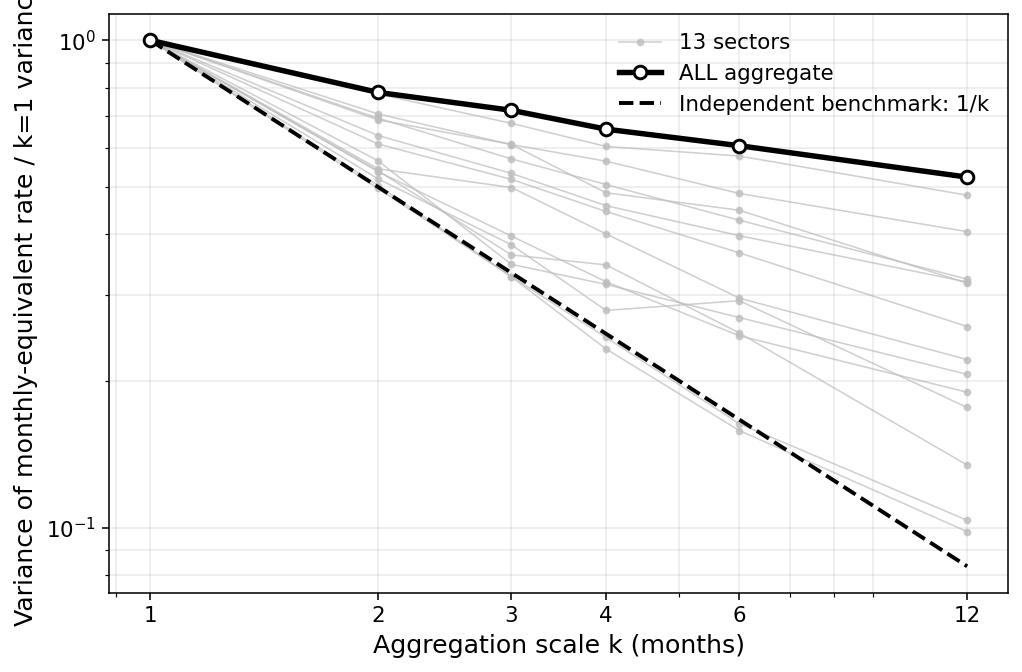

In [6]:
# ============================================================
# Figure 1 and tables: variance scaling of monthly-equivalent rates
# ============================================================

summary_all_k = (
    df_kmonth_sector
    .groupby(["sector", "k_month"])
    .agg(
        n_blocks=("L", "size"),
        mean_default_rate_per_month=("default_rate_per_month", "mean"),
        var_default_rate_per_month=("default_rate_per_month", "var"),
    )
    .reset_index()
)

base_var_all = (
    summary_all_k
    .query("k_month == 1")
    .set_index("sector")["var_default_rate_per_month"]
)

summary_all_k["var_k1"] = summary_all_k["sector"].map(base_var_all)
summary_all_k["variance_ratio_to_k1"] = (
    summary_all_k["var_default_rate_per_month"] / summary_all_k["var_k1"]
)
summary_all_k["independent_1_over_k"] = 1.0 / summary_all_k["k_month"]
summary_all_k["ratio_to_independent"] = (
    summary_all_k["variance_ratio_to_k1"] / summary_all_k["independent_1_over_k"]
)

summary_sector_k = summary_all_k.query("sector != 'ALL'").copy()
summary_ALL_k = summary_all_k.query("sector == 'ALL'").sort_values("k_month").copy()

save_table(summary_all_k, "table03_sector_and_ALL_variance_scaling")

if len(summary_ALL_k) > 0:
    var_scaling_ALL = (
        summary_ALL_k[
            [
                "k_month",
                "n_blocks",
                "mean_default_rate_per_month",
                "var_default_rate_per_month",
                "variance_ratio_to_k1",
                "independent_1_over_k",
                "ratio_to_independent",
            ]
        ]
        .reset_index(drop=True)
    )
    save_table(var_scaling_ALL, "table04_ALL_variance_scaling_by_k")

fig, ax = plt.subplots(figsize=(7.4, 4.9))

first_sector = True
for sector, g in summary_sector_k.groupby("sector"):
    g = g.sort_values("k_month")
    ax.plot(
        g["k_month"],
        g["variance_ratio_to_k1"],
        marker="o",
        linewidth=0.8,
        markersize=3.0,
        color="0.75",
        alpha=0.75,
        label="13 sectors" if first_sector else None,
        zorder=1,
    )
    first_sector = False

if len(summary_ALL_k) > 0:
    ax.plot(
        summary_ALL_k["k_month"],
        summary_ALL_k["variance_ratio_to_k1"],
        linestyle="-",
        marker="o",
        linewidth=2.8,
        markersize=6.5,
        color="black",
        markerfacecolor="white",
        markeredgewidth=1.5,
        label="ALL aggregate",
        zorder=3,
    )

k_arr = np.asarray(K_LIST, dtype=float)
ax.plot(
    k_arr,
    1.0 / k_arr,
    linestyle="--",
    linewidth=2.0,
    color="black",
    label="Independent benchmark: 1/k",
    zorder=2,
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(K_LIST)
ax.set_xticklabels([str(k) for k in K_LIST], fontsize=11)
ax.set_xlabel("Aggregation scale k (months)", fontsize=13)
ax.set_ylabel("Variance of monthly-equivalent rate / k=1 variance", fontsize=13)
ax.tick_params(axis="both", labelsize=11)
ax.legend(frameon=False, fontsize=11)
ax.grid(True, which="both", alpha=0.25)

fig.tight_layout()
savefig(fig, "fig01_variance_scaling_monthly_equivalent_rates")
plt.show()

## Figure 2. Empirical eigenvalue scaling

This figure shows how the eigenvalues of the sector correlation matrix change with the temporal aggregation scale.

saved: tables\table05_empirical_eigenvalue_scaling_long.csv


,k_month,eigen_index,eigenvalue
0,1,1,2.484813
1,1,2,1.327561
2,1,3,1.181079
3,1,4,1.151299
4,1,5,1.058577
5,1,6,0.995597
6,1,7,0.883513
7,1,8,0.771356
8,1,9,0.729335
9,1,10,0.727499


saved: tables\table06_empirical_eigenvalue_scaling_wide.csv


eigen_index,k_month,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1,2.484813,1.327561,1.181079,1.151299,1.058577,0.995597,0.883513,0.771356,0.729335,0.727499,0.608325,0.590550,0.490495
1,2,3.225096,1.521295,1.201086,1.130238,1.034821,0.974181,0.785433,0.724009,0.584400,0.555323,0.525747,0.393547,0.344827
2,3,3.633893,1.547176,1.252843,1.142015,0.903298,0.880672,0.782160,0.710132,0.548453,0.495078,0.437243,0.363358,0.303679
3,4,4.020300,1.685786,1.198019,1.083474,1.013568,0.939167,0.699083,0.608486,0.513322,0.405333,0.328883,0.284406,0.220174
4,6,4.362918,1.821128,1.335503,1.113004,0.887780,0.841550,0.666812,0.636451,0.454825,0.297817,0.275024,0.166136,0.141054
5,12,5.232819,2.004328,1.250514,1.008519,0.934456,0.693728,0.663558,0.452252,0.256344,0.192880,0.167495,0.086972,0.056133


saved: figures\fig02_empirical_eigenvalue_scaling.png
saved: figures\fig02_empirical_eigenvalue_scaling.pdf


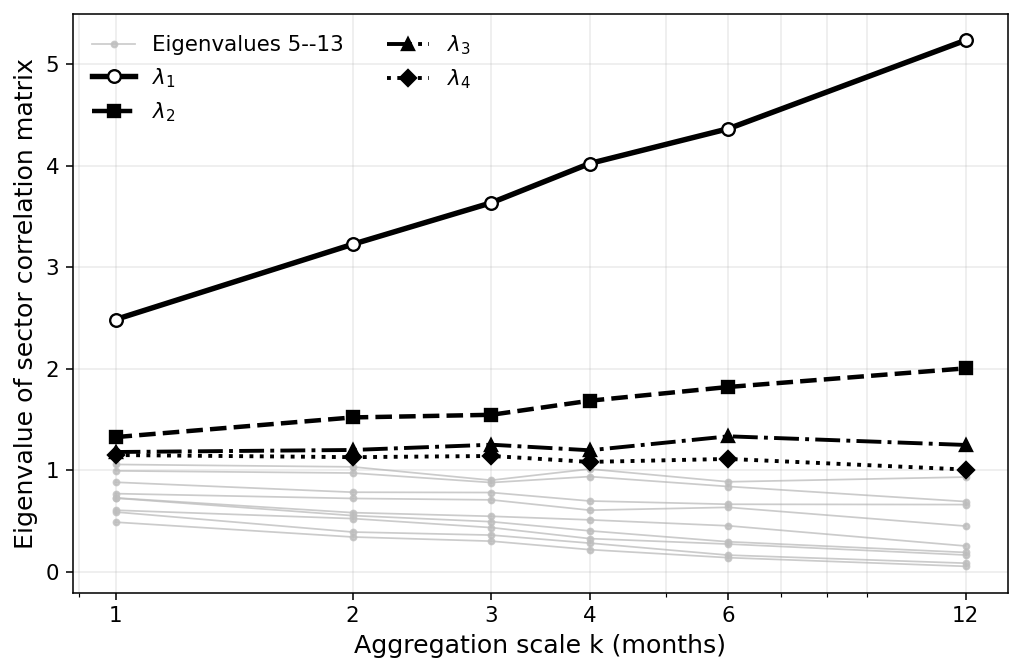

In [7]:
# ============================================================
# Figure 2 and tables: empirical eigenvalue scaling by k
# ============================================================

eig_records = []

for k in K_LIST:
    panel_k = make_sector_panel(
        df_kmonth_sector,
        k=k,
        value="default_rate_per_month",
        include_all=False,
    )

    panel_k = panel_k.dropna(axis=1, how="all")
    Ck = panel_k.corr()
    Ck = 0.5 * (Ck.values + Ck.values.T)

    eigvals = np.linalg.eigvalsh(Ck)[::-1]

    for j, lam in enumerate(eigvals, start=1):
        eig_records.append({
            "k_month": k,
            "eigen_index": j,
            "eigenvalue": lam,
        })

eig_scaling_long = pd.DataFrame(eig_records)

eig_scaling_wide = (
    eig_scaling_long
    .pivot(index="k_month", columns="eigen_index", values="eigenvalue")
    .reset_index()
)

save_table(eig_scaling_long, "table05_empirical_eigenvalue_scaling_long")
save_table(eig_scaling_wide, "table06_empirical_eigenvalue_scaling_wide")

fig, ax = plt.subplots(figsize=(7.4, 4.9))

eig_bg = eig_scaling_long.query("eigen_index >= 5")
for j, g in eig_bg.groupby("eigen_index"):
    g = g.sort_values("k_month")
    ax.plot(
        g["k_month"],
        g["eigenvalue"],
        color="0.75",
        linewidth=0.9,
        marker="o",
        markersize=3.0,
        alpha=0.8,
        label="Eigenvalues 5--13" if j == 5 else None,
        zorder=1,
    )

style_map = {
    1: {"linestyle": "-",  "marker": "o", "linewidth": 2.8, "markersize": 6.5},
    2: {"linestyle": "--", "marker": "s", "linewidth": 2.3, "markersize": 5.8},
    3: {"linestyle": "-.", "marker": "^", "linewidth": 2.0, "markersize": 5.8},
    4: {"linestyle": ":",  "marker": "D", "linewidth": 2.0, "markersize": 5.5},
}

for j in [1, 2, 3, 4]:
    g = eig_scaling_long.query("eigen_index == @j").sort_values("k_month")
    ax.plot(
        g["k_month"],
        g["eigenvalue"],
        color="black",
        markerfacecolor="white" if j == 1 else "black",
        markeredgecolor="black",
        markeredgewidth=1.2,
        label=rf"$\lambda_{j}$",
        zorder=3,
        **style_map[j],
    )

ax.set_xscale("log")
ax.set_xticks(K_LIST)
ax.set_xticklabels([str(k) for k in K_LIST], fontsize=11)
ax.set_xlabel("Aggregation scale k (months)", fontsize=13)
ax.set_ylabel("Eigenvalue of sector correlation matrix", fontsize=13)
ax.tick_params(axis="both", labelsize=11)
ax.legend(frameon=False, fontsize=11, ncol=2)
ax.grid(True, which="both", alpha=0.25)

fig.tight_layout()
savefig(fig, "fig02_empirical_eigenvalue_scaling")
plt.show()

## Figure 3. Empirical *k=1* eigenstructure

The first two empirical eigenvectors of the monthly sector correlation matrix define the fixed loading directions used later.

saved: tables\table07_empirical_k1_eigenvalues.csv


,rank,eigval_k1,explained_share,cumulative_share
0,1,2.484813,0.191139,0.191139
1,2,1.327561,0.102120,0.293260
2,3,1.181079,0.090852,0.384112
3,4,1.151299,0.088561,0.472673
4,5,1.058577,0.081429,0.554102
5,6,0.995597,0.076584,0.630687
6,7,0.883513,0.067963,0.698649
7,8,0.771356,0.059335,0.757984
8,9,0.729335,0.056103,0.814087
9,10,0.727499,0.055961,0.870048


saved: tables\table08_empirical_k1_eigenvectors_v1_to_v4.csv


,sector,v1_k1,v2_k1,v3_k1,v4_k1
0,Consumer,0.357267,-0.102441,-0.003229,0.212493
1,Energy,0.090580,-0.171806,0.307697,0.390953
2,FI,0.167333,0.131518,0.517703,-0.308538
3,Forest,0.359664,0.452411,-0.095425,0.019512
4,Health,0.317839,-0.046721,0.448283,0.036231
5,High Tech,0.236053,0.035415,-0.127922,0.179913
6,Insurance,0.090488,-0.126642,-0.144526,0.527195
7,Leisure,0.376065,0.297460,0.112946,-0.095540
8,Metal,0.427610,-0.107997,0.001600,-0.123306
9,Real Estate,0.160230,0.505160,-0.428898,0.055576


saved: figures\fig03a_empirical_k1_eigenvalue_spectrum.png
saved: figures\fig03a_empirical_k1_eigenvalue_spectrum.pdf


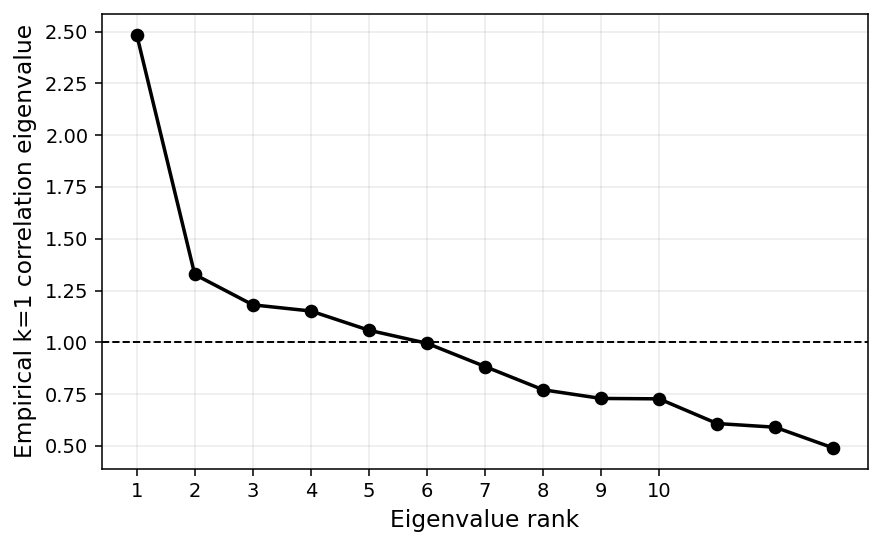

saved: figures\fig03_empirical_k1_eigenvectors_v1_v2.png
saved: figures\fig03_empirical_k1_eigenvectors_v1_v2.pdf


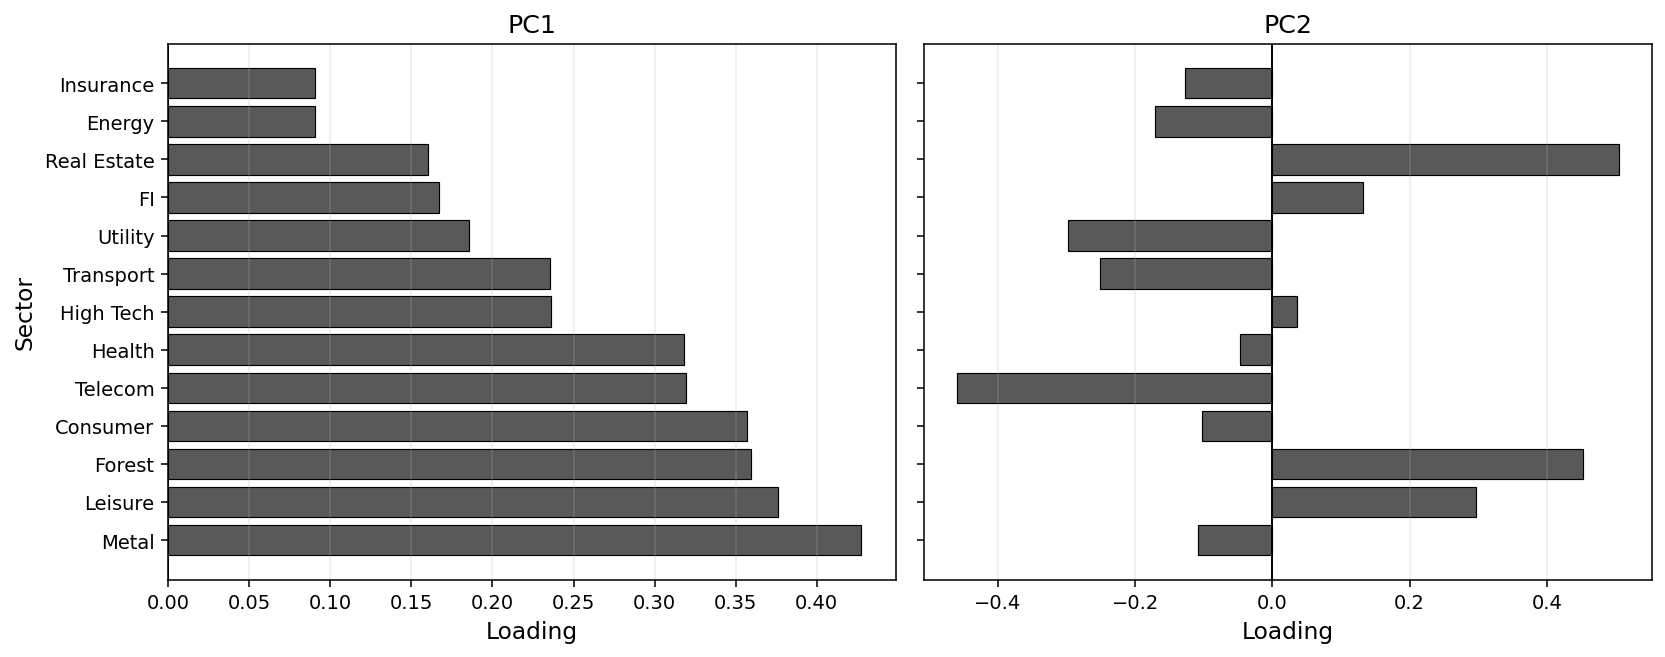

PC2 loadings, descending:


,sector,v2_k1
0,Real Estate,0.505160
1,Forest,0.452411
2,Leisure,0.297460
3,FI,0.131518
4,High Tech,0.035415
5,Health,-0.046721
6,Consumer,-0.102441
7,Metal,-0.107997
8,Insurance,-0.126642
9,Energy,-0.171806


In [8]:
# ============================================================
# Figure 3 and tables: empirical k=1 eigenstructure
# ============================================================

panel1 = make_sector_panel(
    df_kmonth_sector,
    k=1,
    value="default_rate_per_month",
    include_all=False,
)

X = panel1.dropna(axis=0, how="any").copy()
X_std = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)

C = X_std.corr().values
C = 0.5 * (C + C.T)

vals, vecs = np.linalg.eigh(C)
order = vals.argsort()[::-1]
vals = vals[order]
vecs = vecs[:, order]

sector_list = list(X.columns)

# PC1: market-wide mode should be broadly positive.
if vecs[:, 0].sum() < 0:
    vecs[:, 0] *= -1.0

# PC2: stable sign convention used in the manuscript.
pc2_positive_anchor = ["Real Estate", "Forest", "Leisure", "FI"]
pc2_negative_anchor = ["Telecom", "Utility", "Transport", "Energy", "Insurance"]

pos_idx = [sector_list.index(s) for s in pc2_positive_anchor if s in sector_list]
neg_idx = [sector_list.index(s) for s in pc2_negative_anchor if s in sector_list]

if pos_idx or neg_idx:
    score_pc2 = vecs[pos_idx, 1].sum() - vecs[neg_idx, 1].sum()
    if score_pc2 < 0:
        vecs[:, 1] *= -1.0
else:
    if vecs[:, 1].sum() < 0:
        vecs[:, 1] *= -1.0

# PC3 and higher: display convention only.
for r in range(2, vecs.shape[1]):
    idx_max = np.argmax(np.abs(vecs[:, r]))
    if vecs[idx_max, r] < 0:
        vecs[:, r] *= -1.0

df_eigenvalues_k1 = pd.DataFrame({
    "rank": np.arange(1, len(vals) + 1),
    "eigval_k1": vals,
    "explained_share": vals / vals.sum(),
    "cumulative_share": np.cumsum(vals) / vals.sum(),
})

df_fixed_eigenvectors_k1 = pd.DataFrame({
    "sector": sector_list,
    "v1_k1": vecs[:, 0],
    "v2_k1": vecs[:, 1],
    "v3_k1": vecs[:, 2],
    "v4_k1": vecs[:, 3],
})

# Downstream compatibility: 03 notebooks can load these names if desired.
df_eigenvalues_k1.to_csv(PDATA_DIR / "empirical_k1_eigenvalues.csv", index=False)
df_fixed_eigenvectors_k1.to_csv(PDATA_DIR / "fixed_eigenvectors_k1_v1_to_v4.csv", index=False)

save_table(df_eigenvalues_k1, "table07_empirical_k1_eigenvalues")
save_table(df_fixed_eigenvectors_k1, "table08_empirical_k1_eigenvectors_v1_to_v4")

fig, ax = plt.subplots(figsize=(6.4, 4.0))

ax.plot(
    df_eigenvalues_k1["rank"],
    df_eigenvalues_k1["eigval_k1"],
    marker="o",
    linewidth=1.8,
    color="black",
)

ax.axhline(1.0, linestyle="--", linewidth=1.0, color="black")
ax.set_xlabel("Eigenvalue rank", fontsize=12)
ax.set_ylabel("Empirical k=1 correlation eigenvalue", fontsize=12)
ax.set_xticks(np.arange(1, min(len(vals), 10) + 1))
ax.tick_params(axis="both", labelsize=10)
ax.grid(alpha=0.25)

fig.tight_layout()
savefig(fig, "fig03a_empirical_k1_eigenvalue_spectrum")
plt.show()

sector_order = (
    df_fixed_eigenvectors_k1
    .sort_values("v1_k1", ascending=False)["sector"]
    .tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8), sharey=True)

for r, ax in zip([1, 2], axes):
    col = f"v{r}_k1"
    sub = (
        df_fixed_eigenvectors_k1[["sector", col]]
        .set_index("sector")
        .loc[sector_order]
        .reset_index()
    )

    ax.barh(
        sub["sector"],
        sub[col],
        color="0.35",
        edgecolor="black",
        linewidth=0.6,
    )

    ax.invert_yaxis()
    ax.axvline(0.0, linewidth=1.0, color="black")
    ax.set_title(f"PC{r}", fontsize=13)
    ax.set_xlabel("Loading", fontsize=12)
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(axis="x", alpha=0.25)

axes[0].set_ylabel("Sector", fontsize=12)

fig.tight_layout()
savefig(fig, "fig03_empirical_k1_eigenvectors_v1_v2")
plt.show()

print("PC2 loadings, descending:")
display(
    df_fixed_eigenvectors_k1[["sector", "v2_k1"]]
    .sort_values("v2_k1", ascending=False)
    .reset_index(drop=True)
)

## Figure 4. Empirical ACF of PC scores

This figure documents the persistence of the leading empirical PC score series at the monthly scale.

saved: pdata\empirical_pc1_pc4_scores_k1.csv
saved: tables\table09_empirical_pc1_pc4_acf_k1.csv


,pc,lag_months,acf
0,PC1,0,1.000000
1,PC1,1,0.673029
2,PC1,2,0.588608
3,PC1,3,0.581306
4,PC1,4,0.504135
5,PC1,5,0.526562
6,PC1,6,0.475696
7,PC1,7,0.382750
8,PC1,8,0.359195
9,PC1,9,0.328774


saved: figures\fig04_empirical_pc1_pc4_acf_k1.png
saved: figures\fig04_empirical_pc1_pc4_acf_k1.pdf


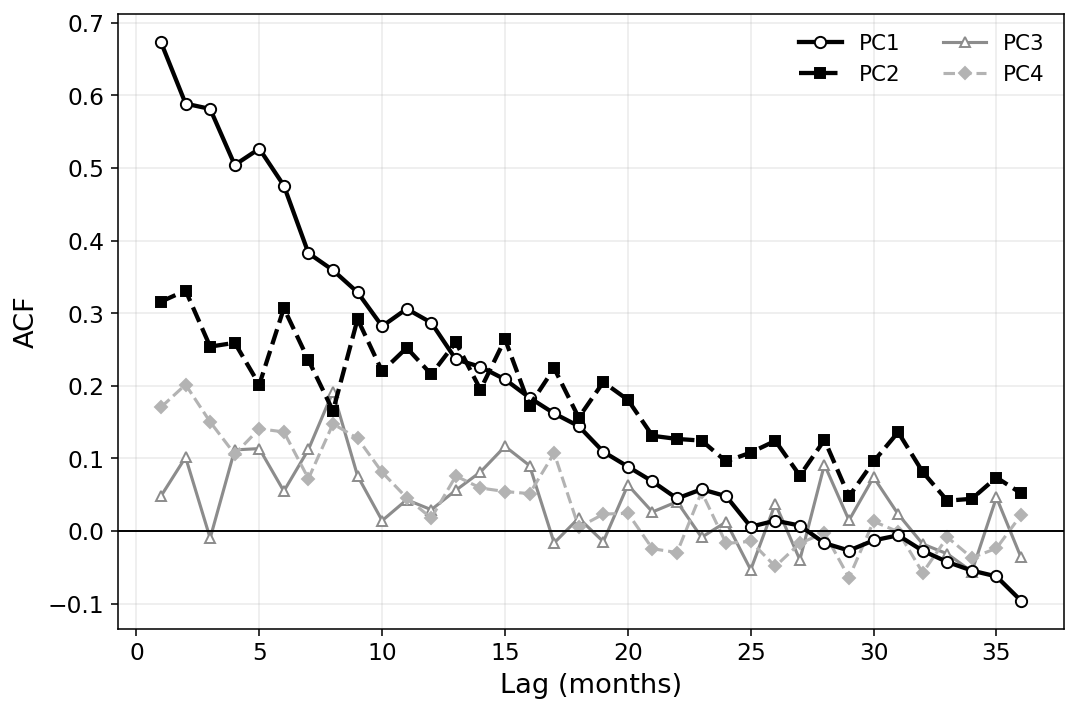

In [9]:
# ============================================================
# Figure 4 and table: empirical ACF of PC1--PC4 scores at k=1
# ============================================================

def compute_acf(x, max_lag):
    x = pd.Series(x).dropna().to_numpy(dtype=float)
    x = x - x.mean()
    denom = np.dot(x, x)
    if denom <= 0:
        out = np.full(max_lag + 1, np.nan)
        out[0] = 1.0
        return out

    vals = []
    for h in range(max_lag + 1):
        if h == 0:
            vals.append(1.0)
        elif h < len(x):
            vals.append(np.dot(x[:-h], x[h:]) / denom)
        else:
            vals.append(np.nan)
    return np.asarray(vals)

panel1 = make_sector_panel(
    df_kmonth_sector,
    k=1,
    value="default_rate_per_month",
    include_all=False,
)

X = panel1.dropna(axis=0, how="any").copy()
X_std = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)

C = X_std.corr().values
vals, vecs = np.linalg.eigh(0.5 * (C + C.T))
order = vals.argsort()[::-1]
vals = vals[order]
vecs = vecs[:, order]

for r in range(4):
    if np.sum(vecs[:, r]) < 0:
        vecs[:, r] = -vecs[:, r]

scores = X_std.values @ vecs[:, :4]
df_pc_scores = pd.DataFrame(
    scores,
    index=X_std.index,
    columns=["PC1", "PC2", "PC3", "PC4"],
).reset_index(names="date")

df_pc_scores.to_csv(PDATA_DIR / "empirical_pc1_pc4_scores_k1.csv", index=False)
print("saved:", PDATA_DIR / "empirical_pc1_pc4_scores_k1.csv")

pc_acf_rows = []
for pc in ["PC1", "PC2", "PC3", "PC4"]:
    acf_vals = compute_acf(df_pc_scores[pc], max_lag=MAX_LAG_MONTHS)
    for lag, acf in enumerate(acf_vals):
        pc_acf_rows.append({
            "pc": pc,
            "lag_months": lag,
            "acf": acf,
        })

df_pc_acf = pd.DataFrame(pc_acf_rows)
save_table(df_pc_acf, "table09_empirical_pc1_pc4_acf_k1")

fig, ax = plt.subplots(figsize=(7.8, 5.2))

style_map = {
    "PC1": {"color": "black", "linestyle": "-",  "marker": "o", "markersize": 5.8, "linewidth": 2.2, "zorder": 4},
    "PC2": {"color": "black", "linestyle": "--", "marker": "s", "markersize": 5.4, "linewidth": 2.2, "zorder": 4},
    "PC3": {"color": "0.55",  "linestyle": "-",  "marker": "^", "markersize": 4.8, "linewidth": 1.6, "zorder": 2},
    "PC4": {"color": "0.70",  "linestyle": "--", "marker": "D", "markersize": 4.6, "linewidth": 1.6, "zorder": 2},
}

for pc in ["PC1", "PC2", "PC3", "PC4"]:
    g = df_pc_acf.query("pc == @pc and lag_months >= 1")
    ax.plot(
        g["lag_months"],
        g["acf"],
        label=pc,
        markerfacecolor="white" if pc in ["PC1", "PC3"] else style_map[pc]["color"],
        markeredgecolor=style_map[pc]["color"],
        markeredgewidth=1.0,
        **style_map[pc],
    )

ax.axhline(0, color="black", linewidth=1.0)
ax.set_xlabel("Lag (months)", fontsize=14)
ax.set_ylabel("ACF", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.legend(frameon=False, fontsize=11, ncol=2)
ax.grid(True, alpha=0.25)

fig.tight_layout()
savefig(fig, "fig04_empirical_pc1_pc4_acf_k1")
plt.show()

## Done

This notebook intentionally stops after the empirical data coarse-graining diagnostics.

The Bayesian factor-selection and dynamic-model notebooks should use the outputs in `./pdata/`, especially:

- `SP_monthly_sector_and_all_kmonth.csv`
- `empirical_k1_eigenvalues.csv`
- `fixed_eigenvectors_k1_v1_to_v4.csv`
- `empirical_pc1_pc4_scores_k1.csv`